# Problema 2 — Regresión: Estimación de Edad a partir de Imágenes Faciales

**Workshop 2 – Machine Learning & Deep Learning Aplicado**  
Universidad EAFIT – Introducción a la Inteligencia Artificial (2026-01)

**Dataset:** Faces Age Detection from Images  
**Fuente:** Kaggle – [arashnic/faces-age-detection-dataset](https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset)

---

## 0. Instalación de dependencias y descarga del dataset

Se usa **`kagglehub`** para descargar el dataset en una sola línea.  
La primera vez pedirá tu **usuario y API key de Kaggle** (se guardan automáticamente).  
Las ejecuciones siguientes usan la caché local — sin volver a descargar.

In [6]:
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["kagglehub", "tqdm", "scikit-learn", "seaborn"]:
    pip_install(pkg)

print("✅ Dependencias instaladas")

✅ Dependencias instaladas


In [7]:
import kagglehub
import shutil
from pathlib import Path

DATA_DIR   = Path("data")
EXTENSIONS = {".jpg", ".jpeg", ".png"}

# Contar imágenes ya presentes (sin explotar si la carpeta no existe)
existing = sum(1 for f in DATA_DIR.rglob("*")
               if f.is_file() and f.suffix.lower() in EXTENSIONS) if DATA_DIR.exists() else 0

if existing > 0:
    print(f"⚡ Dataset ya presente en '{DATA_DIR}/' ({existing:,} imágenes) — omitiendo descarga.")
else:
    print("⬇️  Descargando dataset con kagglehub...")
    print("   (La primera vez pedirá usuario y API key de Kaggle)\n")

    cache_path = Path(kagglehub.dataset_download("arashnic/faces-age-detection-dataset"))
    print(f"\n   Caché en: {cache_path}")

    # Buscar la subcarpeta con más imágenes
    best_folder, best_count = cache_path, 0
    for folder in [cache_path, *cache_path.rglob("*")]:
        folder = Path(folder)
        if folder.is_dir():
            count = sum(1 for f in folder.iterdir()
                        if f.is_file() and f.suffix.lower() in EXTENSIONS)
            if count > best_count:
                best_count, best_folder = count, folder

    if best_count == 0:
        raise FileNotFoundError(f"No se encontraron imágenes en la caché: {cache_path}")

    print(f"   {best_count:,} imágenes encontradas en: {best_folder}")

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print(f"📁 Copiando imágenes a '{DATA_DIR}/'...")
    for img_path in best_folder.iterdir():
        if img_path.is_file() and img_path.suffix.lower() in EXTENSIONS:
            shutil.copy2(img_path, DATA_DIR / img_path.name)

    total = sum(1 for f in DATA_DIR.iterdir() if f.suffix.lower() in EXTENSIONS)
    print(f"\n✅ Dataset listo en '{DATA_DIR}/'  —  {total:,} imágenes")


⚡ Dataset ya presente en 'data/' (19,906 imágenes) — omitiendo descarga.


In [8]:
import os, re, random, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import PIL.Image as PILImage
from pathlib import Path
from sklearn.metrics import r2_score
from tqdm import tqdm

DATA_DIR    = Path("data")
DATASET_DIR = Path("dataset")
EXTENSIONS  = {".jpg", ".jpeg", ".png"}

# Mapeo de clases textuales → valores numéricos representativos para regresión
# YOUNG  (0–30 años)  → 22
# MIDDLE (31–55 años) → 42
# OLD    (56+ años)   → 65
AGE_LABEL_MAP = {"YOUNG": 22, "MIDDLE": 42, "OLD": 65}

IMG_SIZE = 128; BATCH_SIZE = 32; NUM_EPOCHS = 30; LR = 1e-3; NUM_WORKERS = 2
TRAIN_RATIO = 0.70; VAL_RATIO = 0.15; TEST_RATIO = 0.15; SEED = 42

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo : {DEVICE}")
imgs = sum(1 for f in DATA_DIR.rglob("*") if f.is_file() and f.suffix.lower() in EXTENSIONS) if DATA_DIR.exists() else 0
print(f"Imágenes    : {imgs:,}")
if imgs == 0:
    raise FileNotFoundError("data/ vacía — ejecuta primero la celda de descarga.")


Dispositivo : cuda
Imágenes    : 19,906


---
## 1. Análisis Preliminar del Problema

### 1a. ¿Por qué es un problema de regresión?

La variable objetivo es la **edad cronológica** del sujeto fotografiado, expresada como un número entero continuo en el rango [0, 116] años. A diferencia de la clasificación, donde el target pertenece a un conjunto discreto de categorías, aquí el modelo debe predecir un valor numérico real — lo que define formalmente un problema de **regresión supervisada**.

Características que confirman esto:
- El target es continuo (o cuasi-continuo): 0, 1, 2, …, 116.
- La distancia entre valores tiene significado real: equivocarse por 5 años es peor que equivocarse por 1 año.
- Las métricas apropiadas son MAE, RMSE y R² — no Accuracy ni F1-Score.
- La función de activación de salida es lineal (sin sigmoid ni softmax).

**Variable objetivo (target):** `age` — número entero extraído del nombre de archivo con el formato `[age]_[gender]_[race]_[datetime].jpg`.

### 1b. Características de entrada

Las entradas son **imágenes faciales RGB** con las siguientes propiedades generales:
- **Espacio de color:** RGB (3 canales).
- **Dimensiones variables** en el dataset original; se redimensionan a **128×128** píxeles para unificar el input del modelo.
- **Rango de píxeles:** [0, 255] → normalizado a distribución ImageNet durante el preprocesamiento.
- **Distribución de edades:** amplia, con posibles sesgos hacia ciertos rangos (se analiza en la sección EDA).

### 1c. Protocolo de adquisición del dataset

El dataset proviene del **UTKFace dataset**, recopilado por investigadores de la Universidad de Tennessee. Las imágenes fueron obtenidas de múltiples fuentes públicas en internet (Flickr, Google Images, etc.) y etiquetadas con la edad, género y etnia del sujeto mediante una combinación de anotación humana y estimación automatizada. El nombre del archivo codifica directamente las etiquetas: `[age]_[gender]_[race]_[datetime].jpg`, donde:
- `age`: edad en años (0–116).
- `gender`: 0 = masculino, 1 = femenino.
- `race`: 0=White, 1=Black, 2=Asian, 3=Indian, 4=Others.
- `datetime`: marca de tiempo de la imagen.

In [9]:
# --- Update: Cargar etiquetas desde train.csv ubicado en la caché de Kaggle ---
# La celda anterior (KbRXXCeh_OWp) copió imágenes a 'data/'
# El usuario ha indicado que train.csv está en:
# /root/.cache/kagglehub/datasets/arashnic/faces-age-detection-dataset/versions/2/faces/train.csv

# Construir la ruta al train.csv basándose en la información del usuario
kaggle_cache_base_path = Path("/root/.cache/kagglehub/datasets/arashnic/faces-age-detection-dataset/versions/2/faces")
csv_file_path = kaggle_cache_base_path / "train.csv"

if not csv_file_path.exists():
    raise FileNotFoundError(f"No se encontró train.csv en la ruta esperada: '{csv_file_path}'.")

df_csv = pd.read_csv(csv_file_path)
print(f"✅ Cargado train.csv desde: {csv_file_path}")

# Asumiendo que el CSV tiene columnas 'filename' y 'class_label'
# El dataset de Kaggle 'arashnic/faces-age-detection-dataset' tiene este formato.
if 'filename' not in df_csv.columns or 'class_label' not in df_csv.columns:
    # Fallback para nombres de columna inesperados, intentar inferir si hay solo 2 columnas.
    if len(df_csv.columns) == 2:
        df_csv.columns = ['filename', 'class_label']
        print("Advertencia: Columnas de train.csv renombradas a ['filename', 'class_label'].")
    else:
        raise ValueError(f"Formato inesperado del train.csv. Se esperaban columnas 'filename' y 'class_label', pero se encontraron: {df_csv.columns.tolist()}")

print(f"Columnas   : {df_csv.columns.tolist()}")
print(f"Filas      : {len(df_csv):,}")
print(f"Clases     : {sorted(df_csv['class_label'].unique())}") # Acceso por nombre de columna

df_csv['age'] = df_csv['class_label'].map(AGE_LABEL_MAP)

unmapped = df_csv['age'].isna().sum()
if unmapped: print(f"⚠️  {unmapped} filas con clase desconocida eliminadas durante el mapeo de edad.")
df_meta = df_csv.dropna(subset=['age']).copy()
df_meta['age'] = df_meta['age'].astype(int)

# Asegurarse de que solo consideramos las imágenes que realmente se copiaron a DATA_DIR
# En la celda KbRXXCeh_OWp, las imágenes se copiaron a DATA_DIR.
existing = {f.name for f in DATA_DIR.rglob("*") if f.is_file() and f.suffix.lower() in EXTENSIONS}
df_meta  = df_meta[df_meta['filename'].isin(existing)].reset_index(drop=True)

print(f"\nTotal con etiqueta válida: {len(df_meta):,}")
print(df_meta.head())

✅ Cargado train.csv desde: /root/.cache/kagglehub/datasets/arashnic/faces-age-detection-dataset/versions/2/faces/train.csv
Advertencia: Columnas de train.csv renombradas a ['filename', 'class_label'].
Columnas   : ['filename', 'class_label']
Filas      : 19,906
Clases     : ['MIDDLE', 'OLD', 'YOUNG']

Total con etiqueta válida: 19,906
    filename class_label  age
0    377.jpg      MIDDLE   42
1  17814.jpg       YOUNG   22
2  21283.jpg      MIDDLE   42
3  16496.jpg       YOUNG   22
4   4487.jpg      MIDDLE   42


---
## 2. Análisis Exploratorio de Datos (EDA)

In [10]:
# ── 2.1 Distribución de clases y estadísticos ───────────────────────────────
print("=== Distribución de clases ===")
print(df_meta['class_label'].value_counts().to_string())
print("\nProporciones:")
print(df_meta['class_label'].value_counts(normalize=True).round(3).to_string())
print(f"\n=== Target numérico (edad mapeada) ===")
print(df_meta['age'].describe().round(2))
print(f"\nMapeo: YOUNG→{AGE_LABEL_MAP['YOUNG']}, MIDDLE→{AGE_LABEL_MAP['MIDDLE']}, OLD→{AGE_LABEL_MAP['OLD']} años")


=== Distribución de clases ===
class_label
MIDDLE    10804
YOUNG      6706
OLD        2396

Proporciones:
class_label
MIDDLE    0.543
YOUNG     0.337
OLD       0.120

=== Target numérico (edad mapeada) ===
count    19906.00
mean        38.03
std         13.52
min         22.00
25%         22.00
50%         42.00
75%         42.00
max         65.00
Name: age, dtype: float64

Mapeo: YOUNG→22, MIDDLE→42, OLD→65 años


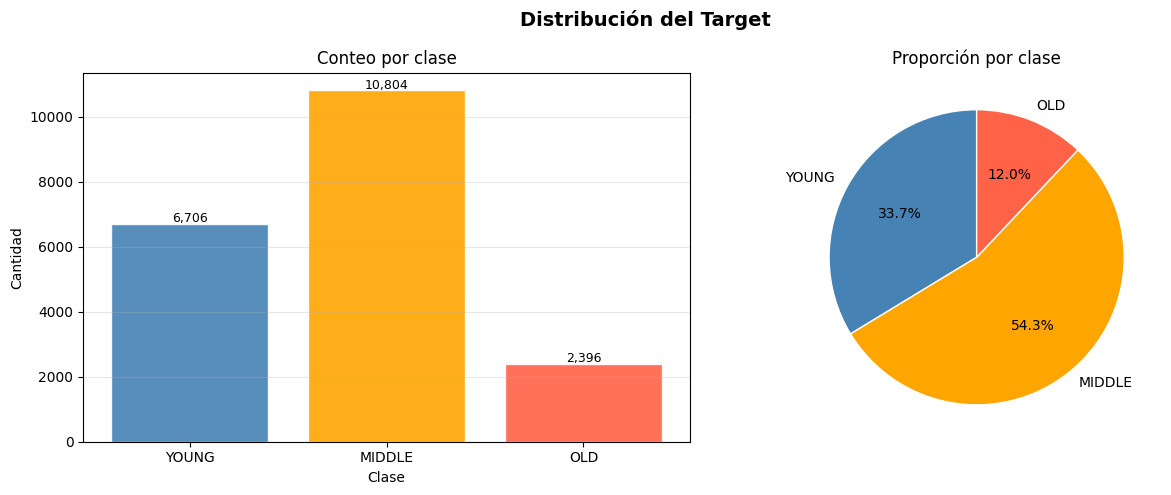


Interpretación:
El dataset está desbalanceado: MIDDLE domina con ~54%, YOUNG ~34%, OLD ~12%.
Para el modelo de regresión esto implica que las predicciones tenderán hacia
el valor MIDDLE (42 años). Una estrategia de mitigación sería WeightedRandomSampler.



In [11]:
# ── 2.2 Distribución del target ─────────────────────────────────────────────
colors = {"YOUNG": "steelblue", "MIDDLE": "orange", "OLD": "tomato"}
order  = ["YOUNG", "MIDDLE", "OLD"]
cc     = df_meta['class_label'].value_counts().reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribución del Target", fontsize=14, fontweight="bold")

bars = axes[0].bar(cc.index, cc.values, color=[colors[c] for c in cc.index], edgecolor='white', alpha=0.9)
for bar, val in zip(bars, cc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'{val:,}', ha='center', fontsize=9)
axes[0].set_title("Conteo por clase"); axes[0].set_xlabel("Clase"); axes[0].set_ylabel("Cantidad")
axes[0].grid(True, alpha=0.3, axis='y')

cc.plot.pie(ax=axes[1], autopct='%1.1f%%', colors=[colors[c] for c in cc.index],
            startangle=90, wedgeprops={'edgecolor':'white'})
axes[1].set_title("Proporción por clase"); axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()
print("""
Interpretación:
El dataset está desbalanceado: MIDDLE domina con ~54%, YOUNG ~34%, OLD ~12%.
Para el modelo de regresión esto implica que las predicciones tenderán hacia
el valor MIDDLE (42 años). Una estrategia de mitigación sería WeightedRandomSampler.
""")


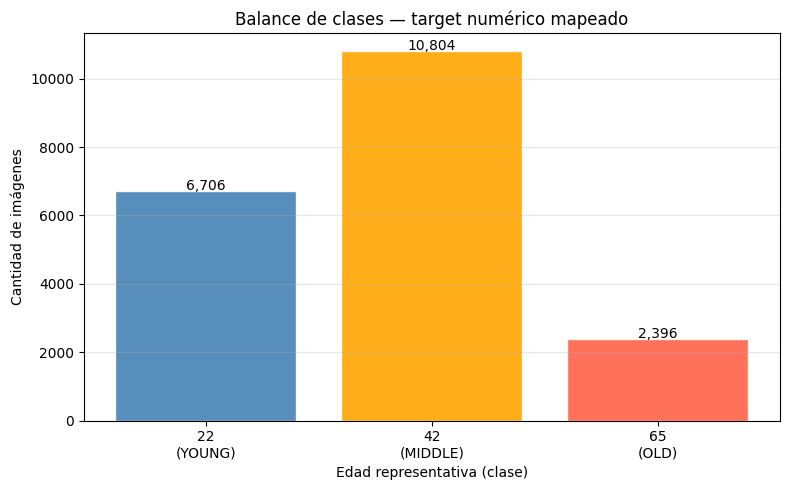


Interpretación:
La clase OLD tiene menos del 12% de los datos, lo que puede sesgar las
predicciones hacia los valores centrales. Esto se refleja en un MAE mayor
para imágenes de personas mayores durante la evaluación final.



In [12]:
# ── 2.3 Análisis de sesgo en el target ──────────────────────────────────────
label_names = {v: k for k, v in AGE_LABEL_MAP.items()}
colors_bar  = {22: 'steelblue', 42: 'orange', 65: 'tomato'}
age_counts  = df_meta['age'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([f"{v}\n({label_names[v]})" for v in age_counts.index],
              age_counts.values,
              color=[colors_bar[v] for v in age_counts.index],
              edgecolor='white', alpha=0.9)
for bar, val in zip(bars, age_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, f'{val:,}', ha='center', fontsize=10)
ax.set_title('Balance de clases — target numérico mapeado')
ax.set_xlabel('Edad representativa (clase)'); ax.set_ylabel('Cantidad de imágenes')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('eda_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print("""
Interpretación:
La clase OLD tiene menos del 12% de los datos, lo que puede sesgar las
predicciones hacia los valores centrales. Esto se refleja en un MAE mayor
para imágenes de personas mayores durante la evaluación final.
""")


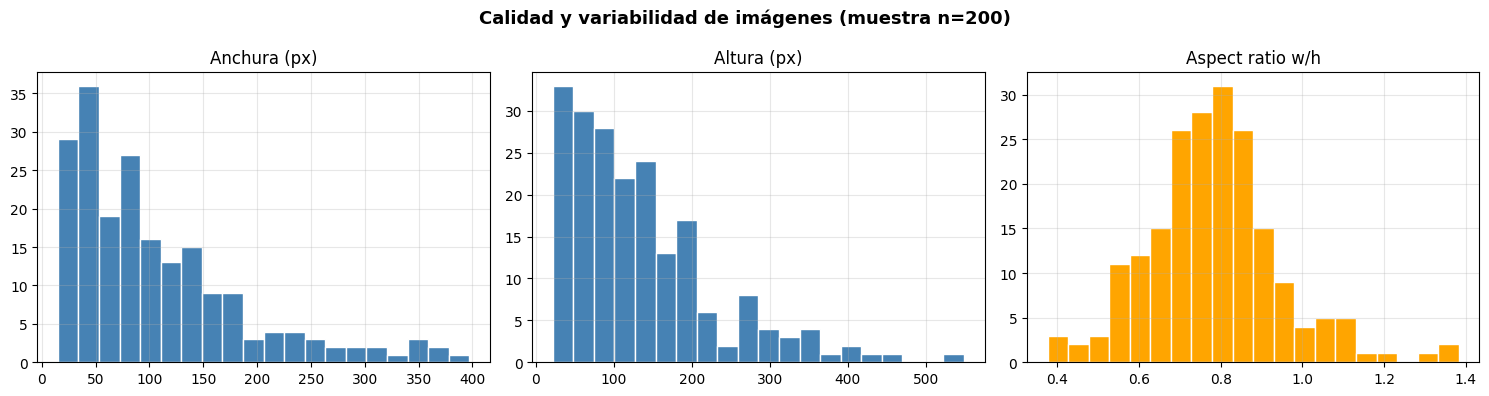

Anchura  — media: 107px  std: 81px
Altura   — media: 135px  std: 95px

Interpretación:
Las imágenes tienen dimensiones variables, lo que confirma la necesidad del
Resize(128x128). Un aspect ratio cercano a 1.0 indica imágenes cuadradas,
favorables porque el redimensionamiento introduce poca distorsión.



In [13]:
# ── 2.4 Calidad y variabilidad de imágenes ───────────────────────────────────
sample_files = df_meta.sample(200, random_state=SEED)['filename'].tolist()
widths, heights = [], []
for fname in sample_files:
    fpath = DATA_DIR / fname
    if fpath.exists():
        try:
            with PILImage.open(fpath) as img:
                w, h = img.size
                widths.append(w); heights.append(h)
        except: pass

aspects = [w/h for w, h in zip(widths, heights)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Calidad y variabilidad de imágenes (muestra n=200)', fontsize=13, fontweight='bold')
axes[0].hist(widths,  bins=20, color='steelblue', edgecolor='white'); axes[0].set_title('Anchura (px)');     axes[0].grid(True, alpha=0.3)
axes[1].hist(heights, bins=20, color='steelblue', edgecolor='white'); axes[1].set_title('Altura (px)');      axes[1].grid(True, alpha=0.3)
axes[2].hist(aspects, bins=20, color='orange',    edgecolor='white'); axes[2].set_title('Aspect ratio w/h'); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_calidad.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Anchura  — media: {np.mean(widths):.0f}px  std: {np.std(widths):.0f}px")
print(f"Altura   — media: {np.mean(heights):.0f}px  std: {np.std(heights):.0f}px")
print("""
Interpretación:
Las imágenes tienen dimensiones variables, lo que confirma la necesidad del
Resize(128x128). Un aspect ratio cercano a 1.0 indica imágenes cuadradas,
favorables porque el redimensionamiento introduce poca distorsión.
""")


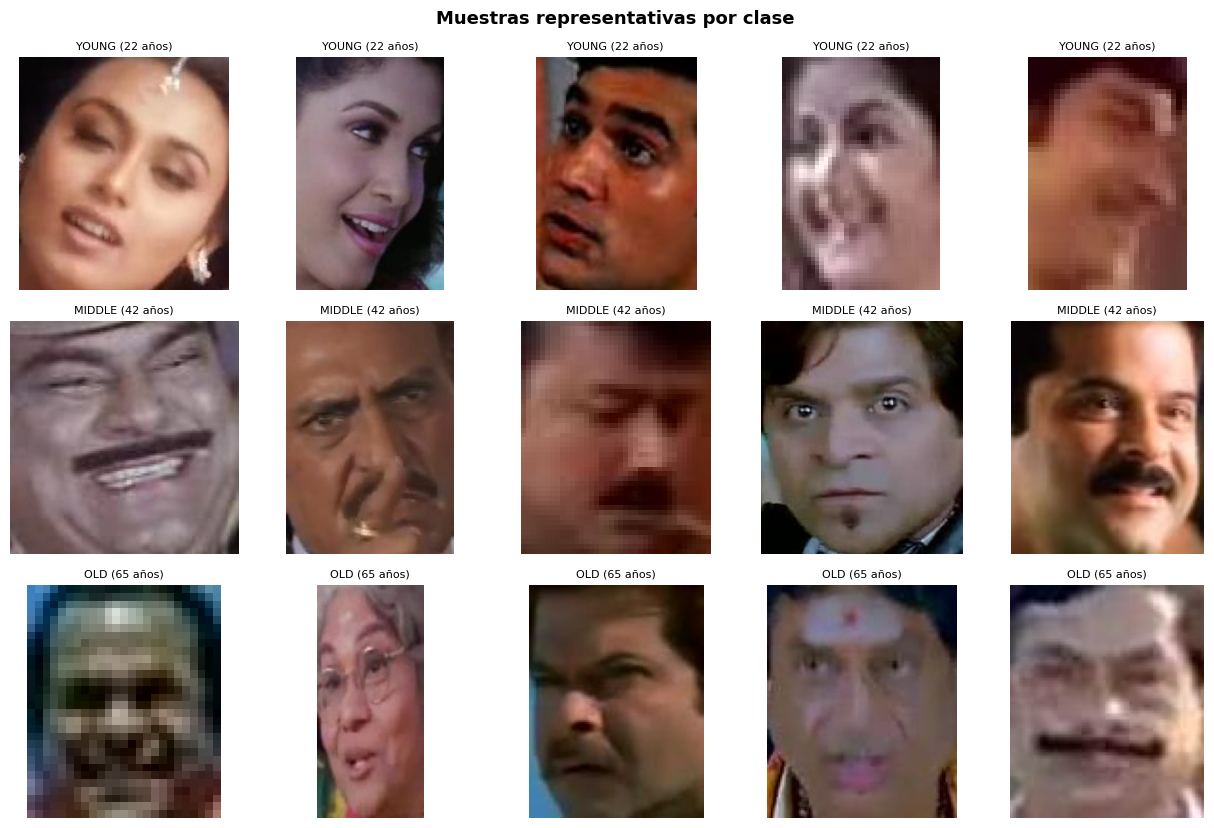


Interpretación:
Las imágenes muestran variabilidad intra-clase en iluminación, ángulo y fondo.
La separación visual YOUNG/OLD es más clara que YOUNG/MIDDLE, lo que anticipa
mayor dificultad del modelo en clases adyacentes.



In [14]:
# ── 2.5 Visualización de muestras por clase ──────────────────────────────────
classes  = ['YOUNG', 'MIDDLE', 'OLD']
n_per    = 5
fig, axes = plt.subplots(3, n_per, figsize=(n_per*2.5, 3*2.8))
fig.suptitle('Muestras representativas por clase', fontsize=13, fontweight='bold')

for row, cls in enumerate(classes):
    subset = df_meta[df_meta['class_label']==cls].sample(
        min(n_per, (df_meta['class_label']==cls).sum()), random_state=SEED)
    for col, (_, r) in enumerate(subset.iterrows()):
        fpath = DATA_DIR / r['filename']
        ax = axes[row][col]
        if fpath.exists(): ax.imshow(PILImage.open(fpath).convert('RGB'))
        ax.set_title(f"{cls} ({r['age']} años)", fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig('eda_muestras_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print("""
Interpretación:
Las imágenes muestran variabilidad intra-clase en iluminación, ángulo y fondo.
La separación visual YOUNG/OLD es más clara que YOUNG/MIDDLE, lo que anticipa
mayor dificultad del modelo en clases adyacentes.
""")


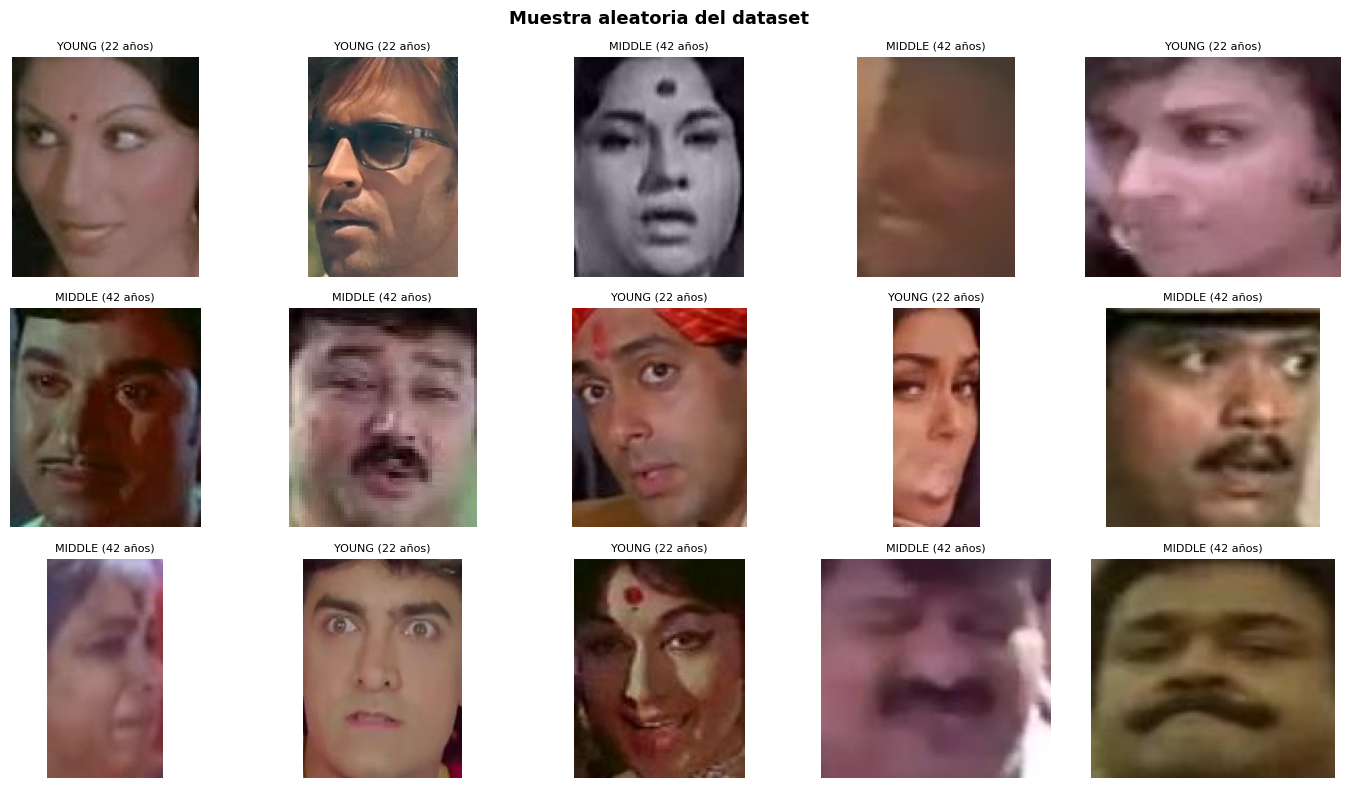

In [15]:
# ── 2.6 Muestra aleatoria de 15 imágenes del dataset ─────────────────────────
sample_rows = df_meta.sample(15, random_state=SEED+1).reset_index(drop=True)
fig, axes   = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle('Muestra aleatoria del dataset', fontsize=13, fontweight='bold')
for ax, (_, r) in zip(axes.flat, sample_rows.iterrows()):
    fpath = DATA_DIR / r['filename']
    if fpath.exists(): ax.imshow(PILImage.open(fpath).convert('RGB'))
    ax.set_title(f"{r['class_label']} ({r['age']} años)", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('eda_muestra_aleatoria.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Procesamiento de Datos

### 3a. División del dataset (70/15/15)

Justificación de la proporción:
- **70% train**: necesitamos suficientes ejemplos para que la CNN aprenda representaciones visuales ricas. Con ~20k imágenes, ~14k son adecuadas.
- **15% val**: se usa para monitorear overfitting y ajustar hiperparámetros sin contaminar el test.
- **15% test**: evaluación final imparcial, usada **solo una vez**.

La división se hace **por archivo** (no por sujeto), con shuffle aleatorio y semilla fija para reproducibilidad.

In [16]:
# ── 3.1 División del dataset 70/15/15 ───────────────────────────────────────
df_shuffled = df_meta.sample(frac=1, random_state=SEED).reset_index(drop=True)

total   = len(df_shuffled)
n_train = int(total * TRAIN_RATIO)
n_val   = int(total * VAL_RATIO)

df_train = df_shuffled.iloc[:n_train].reset_index(drop=True)
df_val   = df_shuffled.iloc[n_train : n_train + n_val].reset_index(drop=True)
df_test  = df_shuffled.iloc[n_train + n_val :].reset_index(drop=True)

print(f"Total imágenes : {total:,}")
print(f"  train : {len(df_train):,} ({len(df_train)/total*100:.1f}%)")
print(f"  val   : {len(df_val):,} ({len(df_val)/total*100:.1f}%)")
print(f"  test  : {len(df_test):,} ({len(df_test)/total*100:.1f}%)")


Total imágenes : 19,906
  train : 13,934 (70.0%)
  val   : 2,985 (15.0%)
  test  : 2,987 (15.0%)


In [17]:
# ── 3.2 Guardar log de la división ──────────────────────────────────────────
# No se copian imágenes — el AgeDataset las lee directo desde data/
# Solo guardamos el log para reproducibilidad.
DATASET_DIR.mkdir(parents=True, exist_ok=True)
log_path = DATASET_DIR / "split_log.csv"

df_train_log = df_train.copy(); df_train_log['split'] = 'train'
df_val_log   = df_val.copy();   df_val_log['split']   = 'val'
df_test_log  = df_test.copy();  df_test_log['split']  = 'test'

pd.concat([df_train_log, df_val_log, df_test_log]).to_csv(log_path, index=False)
print(f"✅ Log guardado en: {log_path}")


✅ Log guardado en: dataset/split_log.csv


In [18]:
# ── 3.3 Transformaciones (preprocesamiento + data augmentation) ───────────────

# Estadísticos ImageNet — usados para normalizar imágenes antes de pasarlas al modelo.
# Son el estándar cuando se trabaja con modelos pre-entrenados en ImageNet.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transformación de ENTRENAMIENTO (con augmentation) ────────────────────────
# El data augmentation crea variaciones artificiales sin guardar copias adicionales:
# - RandomHorizontalFlip: el rostro es simétrico → no cambia la edad.
# - RandomRotation: simula diferentes ángulos de captura.
# - ColorJitter: simula variaciones de iluminación y contraste.
# - RandomAffine: pequeñas deformaciones geométricas.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Transformación de VALIDACIÓN / TEST (sin augmentation) ───────────────────
# Se evalúa con imágenes limpias y consistentes para medir el desempeño real.
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transformaciones definidas ✓")
print("  Train: Resize → Flip → Rotate → ColorJitter → Affine → ToTensor → Normalize")
print("  Val  : Resize → ToTensor → Normalize")

Transformaciones definidas ✓
  Train: Resize → Flip → Rotate → ColorJitter → Affine → ToTensor → Normalize
  Val  : Resize → ToTensor → Normalize


In [19]:
# ── Dataset personalizado ────────────────────────────────────────────────────
class AgeDataset(Dataset):
    """
    Dataset para estimación de edad a partir de imágenes faciales.
    Recibe un DataFrame con columnas ['filename', 'age'] y la ruta a la carpeta
    de imágenes. Compatible tanto con nombres simples (0.jpg) como UTKFace.
    """

    def __init__(self, img_dir: Path, df: pd.DataFrame, transform=None):
        """
        Args:
            img_dir   : carpeta donde están las imágenes (ej: dataset/train)
            df        : DataFrame con columnas 'filename' y 'age'
            transform : transformaciones torchvision
        """
        self.transform = transform
        self.samples = []

        missing = 0
        for _, row in df.iterrows():
            img_path = img_dir / str(row['filename'])
            if img_path.exists():
                self.samples.append((img_path, float(row['age'])))
            else:
                missing += 1

        if missing > 0:
            print(f"  ⚠️  {missing} archivos no encontrados en '{img_dir}' (ignorados)")
        print(f"  [{img_dir.name}] {len(self.samples):,} imágenes cargadas")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, age = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(age, dtype=torch.float32)


print("Clase AgeDataset definida ✓")


Clase AgeDataset definida ✓


In [20]:
print("Construyendo datasets...")
train_dataset = AgeDataset(DATA_DIR, df_train, transform=train_transform)
val_dataset   = AgeDataset(DATA_DIR, df_val,   transform=val_transform)
test_dataset  = AgeDataset(DATA_DIR, df_test,  transform=val_transform)

print(f"\nTotal: {len(train_dataset) + len(val_dataset) + len(test_dataset):,} imágenes")


Construyendo datasets...
  [data] 13,934 imágenes cargadas
  [data] 2,985 imágenes cargadas
  [data] 2,987 imágenes cargadas

Total: 19,906 imágenes


In [21]:
# ── 3.5 DataLoaders ───────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"), drop_last=True)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))

print("DataLoaders creados ✓")
print(f"  Train → {len(train_loader)} batches × {BATCH_SIZE} imgs")
print(f"  Val   → {len(val_loader)} batches × {BATCH_SIZE} imgs")
print(f"  Test  → {len(test_loader)} batches × {BATCH_SIZE} imgs")

DataLoaders creados ✓
  Train → 435 batches × 32 imgs
  Val   → 94 batches × 32 imgs
  Test  → 94 batches × 32 imgs


---
## 4. Arquitectura CNN para Regresión

### Diseño y justificación de la arquitectura

Se diseñó una CNN personalizada con las siguientes decisiones arquitectónicas:

| Componente | Decisión | Justificación |
|---|---|---|
| Bloques conv | 4 bloques Conv→BN→ReLU→MaxPool | Extracción progresiva de features (bordes → texturas → formas → estructuras faciales) |
| BatchNorm2d | Después de cada conv | Estabiliza el entrenamiento y permite LR más alto |
| Dropout | p=0.4 en la FC | Regularización contra overfitting |
| GlobalAvgPool | Antes del FC | Reduce parámetros vs Flatten, más robusto a variaciones de tamaño |
| Capas densas | 512 → 256 → 1 | Capacidad suficiente sin sobreajustar |
| Activación salida | Lineal (sin activación) | La edad es un valor real sin límite impuesto |
| Loss | MSELoss | Penaliza errores grandes cuadráticamente, apropiada para regresión |
| Métricas | MAE, RMSE, R² | MAE = interpretable en años; RMSE = sensible a outliers; R² = varianza explicada |

In [22]:
class AgeCNN(nn.Module):
    """
    CNN para regresión de edad a partir de imágenes faciales.

    Arquitectura:
        4 bloques Conv → BatchNorm → ReLU → MaxPool
        GlobalAveragePooling
        FC: 512 → 256 → 1
    """

    def __init__(self, dropout_rate: float = 0.4):
        super().__init__()

        def conv_block(in_ch, out_ch, kernel=3, padding=1):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=kernel, padding=padding, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),  # reduce resolución a la mitad
            )

        # ── Feature extractor ────────────────────────────────────────────────
        # Input: [B, 3, 128, 128]
        self.features = nn.Sequential(
            conv_block(3,   32),    # → [B, 32,  64, 64]
            conv_block(32,  64),    # → [B, 64,  32, 32]
            conv_block(64,  128),   # → [B, 128, 16, 16]
            conv_block(128, 256),   # → [B, 256,  8,  8]
        )

        # ── Global Average Pooling ──────────────────────────────────────────
        # Promedia cada mapa de features → [B, 256]
        # Ventaja: muchos menos parámetros que Flatten (256 vs 256×8×8=16384)
        self.gap = nn.AdaptiveAvgPool2d(1)

        # ── Regresor ─────────────────────────────────────────────────────────
        self.regressor = nn.Sequential(
            nn.Flatten(),           # [B, 256, 1, 1] → [B, 256]
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(256, 1),      # salida: edad predicha (escalar)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.regressor(x)
        return x   # [B, 1]


model = AgeCNN(dropout_rate=0.4).to(DEVICE)
print(model)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros totales     : {total_params:,}")
print(f"Parámetros entrenables : {trainable_params:,}")

AgeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  

In [23]:
# ── Verificar forward pass ─────────────────────────────────────────────────────
with torch.no_grad():
    dummy = torch.randn(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out = model(dummy)
    print(f"Input : {tuple(dummy.shape)}")
    print(f"Output: {tuple(out.shape)}  ← [batch_size, 1]")

Input : (32, 3, 128, 128)
Output: (32, 1)  ← [batch_size, 1]


In [24]:
# ── Función de pérdida, optimizador y scheduler ────────────────────────────────
criterion = nn.MSELoss()           # MSE para backprop
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# ReduceLROnPlateau: si val_loss no mejora en 4 épocas, reduce LR a la mitad
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4
)

def compute_mae(preds, targets):
    """MAE en años — más interpretable que MSE."""
    return torch.abs(preds - targets).mean().item()

print("Loss      : MSELoss")
print("Métrica   : MAE (años), RMSE (años), R²")
print(f"Optimizer : Adam  lr={LR}  weight_decay=1e-4")
print("Scheduler : ReduceLROnPlateau (patience=4, factor=0.5)")

Loss      : MSELoss
Métrica   : MAE (años), RMSE (años), R²
Optimizer : Adam  lr=0.001  weight_decay=1e-4
Scheduler : ReduceLROnPlateau (patience=4, factor=0.5)


---
## 5. Loop de Entrenamiento

In [25]:
history = {"train_loss": [], "val_loss": [],
           "train_mae":  [], "val_mae":  [],
           "lr":         []}

best_val_mae    = float("inf")
best_model_path = "best_age_model.pth"

print(f"{'Época':>5} | {'Train MSE':>9} | {'Train MAE':>9} | {'Val MSE':>8} | {'Val MAE':>8} | LR")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):

    # ── FASE ENTRENAMIENTO ────────────────────────────────────────────────────
    model.train()
    t_loss, t_mae = 0.0, 0.0

    for imgs, ages in train_loader:
        imgs = imgs.to(DEVICE)
        ages = ages.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs).squeeze(1)      # [B,1] → [B]
        loss  = criterion(preds, ages)
        loss.backward()
        optimizer.step()

        t_loss += loss.item()
        t_mae  += compute_mae(preds.detach(), ages.detach())

    train_loss = t_loss / len(train_loader)
    train_mae  = t_mae  / len(train_loader)

    # ── FASE VALIDACIÓN ───────────────────────────────────────────────────────
    model.eval()
    v_loss, v_mae = 0.0, 0.0

    with torch.no_grad():
        for imgs, ages in val_loader:
            imgs = imgs.to(DEVICE)
            ages = ages.to(DEVICE)
            preds = model(imgs).squeeze(1)
            v_loss += criterion(preds, ages).item()
            v_mae  += compute_mae(preds, ages)

    val_loss = v_loss / len(val_loader)
    val_mae  = v_mae  / len(val_loader)

    # Scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    # Guardar mejor modelo
    marker = ""
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), best_model_path)
        marker = " ← ✓"

    # Historial
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)
    history["lr"].append(current_lr)

    print(f"{epoch:>5} | {train_loss:>9.2f} | {train_mae:>9.2f} | "
          f"{val_loss:>8.2f} | {val_mae:>8.2f} | {current_lr:.1e}{marker}")

print(f"\nMejor Val MAE: {best_val_mae:.2f} años")

Época | Train MSE | Train MAE |  Val MSE |  Val MAE | LR
------------------------------------------------------------------------
    1 |    210.35 |     11.45 |   161.96 |     9.79 | 1.0e-03 ← ✓
    2 |    172.96 |     10.53 |   160.74 |    10.33 | 1.0e-03
    3 |    168.96 |     10.40 |   151.42 |     9.73 | 1.0e-03 ← ✓
    4 |    166.94 |     10.33 |   172.69 |    10.62 | 1.0e-03
    5 |    162.73 |     10.16 |   145.28 |     9.62 | 1.0e-03 ← ✓
    6 |    164.19 |     10.20 |   183.13 |    10.70 | 1.0e-03
    7 |    160.56 |     10.08 |   163.03 |    10.29 | 1.0e-03
    8 |    159.93 |     10.07 |   172.56 |    10.46 | 1.0e-03
    9 |    158.17 |     10.01 |   141.85 |     9.38 | 1.0e-03 ← ✓
   10 |    156.49 |      9.90 |   143.67 |     9.49 | 1.0e-03
   11 |    155.62 |      9.92 |   164.93 |    10.14 | 1.0e-03
   12 |    151.71 |      9.79 |   136.25 |     9.22 | 1.0e-03 ← ✓
   13 |    151.03 |      9.77 |   130.09 |     8.90 | 1.0e-03 ← ✓
   14 |    151.61 |      9.78 |   130.16

---
## 6. Curvas de Aprendizaje y Diagnóstico de Overfitting

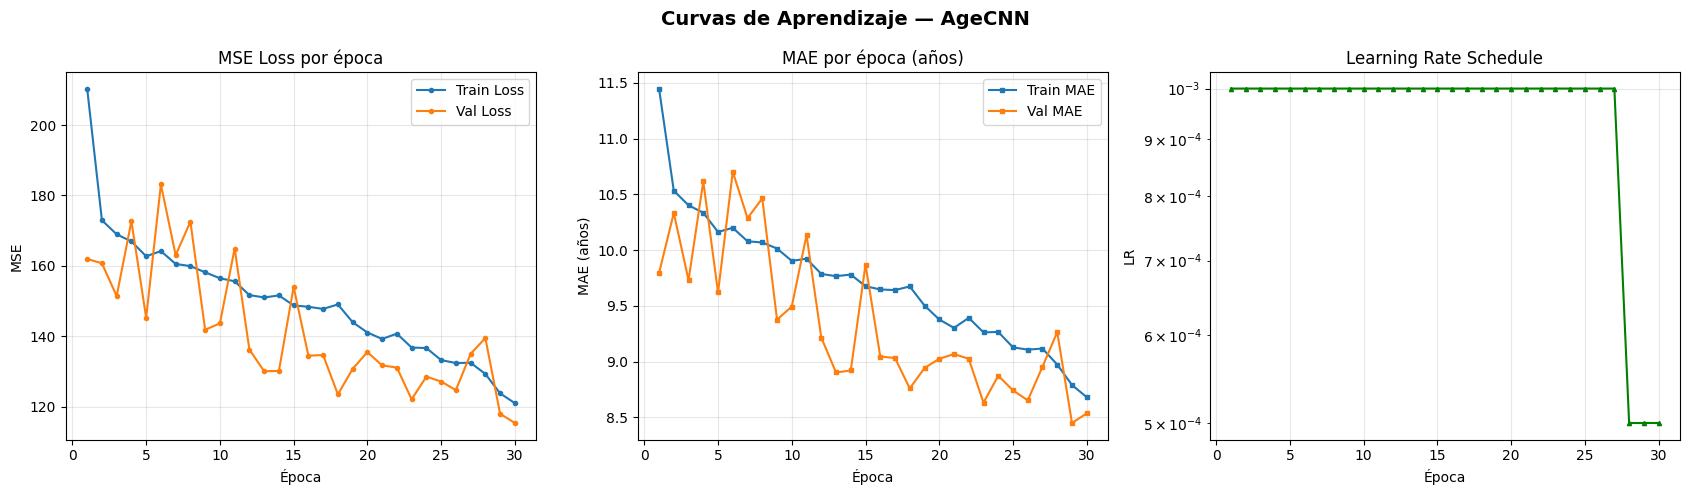


=== Diagnóstico final ===
  Train MAE final : 8.68 años
  Val MAE final   : 8.54 años
  Gap Train↔Val   : -0.14 años  → Buen balance entre train y validación


In [26]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Curvas de Aprendizaje — AgeCNN", fontsize=14, fontweight="bold")

# ── MSE Loss ──────────────────────────────────────────────────────────────────
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o", ms=3)
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="o", ms=3)
axes[0].set_title("MSE Loss por época")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("MSE")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── MAE ───────────────────────────────────────────────────────────────────────
axes[1].plot(epochs_range, history["train_mae"], label="Train MAE", marker="s", ms=3)
axes[1].plot(epochs_range, history["val_mae"],   label="Val MAE",   marker="s", ms=3)
axes[1].set_title("MAE por época (años)")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("MAE (años)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ── Learning Rate ─────────────────────────────────────────────────────────────
axes[2].plot(epochs_range, history["lr"], color="green", marker="^", ms=3)
axes[2].set_title("Learning Rate Schedule")
axes[2].set_xlabel("Época"); axes[2].set_ylabel("LR")
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale("log")

plt.tight_layout()
plt.savefig("curvas_aprendizaje.png", dpi=150, bbox_inches="tight")
plt.show()

# Diagnóstico
gap = history["val_mae"][-1] - history["train_mae"][-1]
print(f"\n=== Diagnóstico final ===")
print(f"  Train MAE final : {history['train_mae'][-1]:.2f} años")
print(f"  Val MAE final   : {history['val_mae'][-1]:.2f} años")
print(f"  Gap Train↔Val   : {gap:.2f} años", end="  ")

if gap > 5:
    print("→ OVERFITTING (gap alto — el modelo memoriza el train pero no generaliza)")
    print("  Estrategias: más Dropout, L2 regularization, más data augmentation, menos parámetros")
elif history["train_mae"][-1] > 10:
    print("→ UNDERFITTING (error alto en train — el modelo no aprendió bien)")
    print("  Estrategias: más épocas, más filtros, menos Dropout, LR más alto")
else:
    print("→ Buen balance entre train y validación")

---
## 7. Evaluación Final en Test Set

> El test set se usa **una sola vez** al final del desarrollo.  
> Usarlo durante el desarrollo introduce sesgo en las decisiones del modelo.

In [27]:
# ── Cargar el mejor modelo guardado ──────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds   = []
all_targets = []

with torch.no_grad():
    for imgs, ages in test_loader:
        imgs  = imgs.to(DEVICE)
        preds = model(imgs).squeeze(1).cpu()
        all_preds.extend(preds.tolist())
        all_targets.extend(ages.tolist())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

# ── Métricas ──────────────────────────────────────────────────────────────────
test_mae  = np.abs(all_preds - all_targets).mean()
test_rmse = np.sqrt(((all_preds - all_targets) ** 2).mean())
test_r2   = r2_score(all_targets, all_preds)

# Métricas de train (última época)
train_mae_final = history["train_mae"][-1]
val_mae_final   = history["val_mae"][-1]
val_loss_final  = history["val_loss"][-1]
train_loss_final = history["train_loss"][-1]

print("\n" + "=" * 55)
print("  TABLA DE MÉTRICAS FINALES")
print("=" * 55)
print(f"  {'Métrica':<10} | {'Train':>10} | {'Val':>10} | {'Test':>10}")
print("-" * 55)
print(f"  {'MAE':<10} | {train_mae_final:>10.2f} | {val_mae_final:>10.2f} | {test_mae:>10.2f}")
print(f"  {'RMSE':<10} | {'—':>10} | {'—':>10} | {test_rmse:>10.2f}")
print(f"  {'R²':<10} | {'—':>10} | {'—':>10} | {test_r2:>10.4f}")
print(f"  {'MSE':<10} | {train_loss_final:>10.2f} | {val_loss_final:>10.2f} | {'—':>10}")
print("=" * 55)


  TABLA DE MÉTRICAS FINALES
  Métrica    |      Train |        Val |       Test
-------------------------------------------------------
  MAE        |       8.68 |       8.54 |       8.51
  RMSE       |          — |          — |      10.96
  R²         |          — |          — |     0.3540
  MSE        |     121.02 |     115.38 |          —


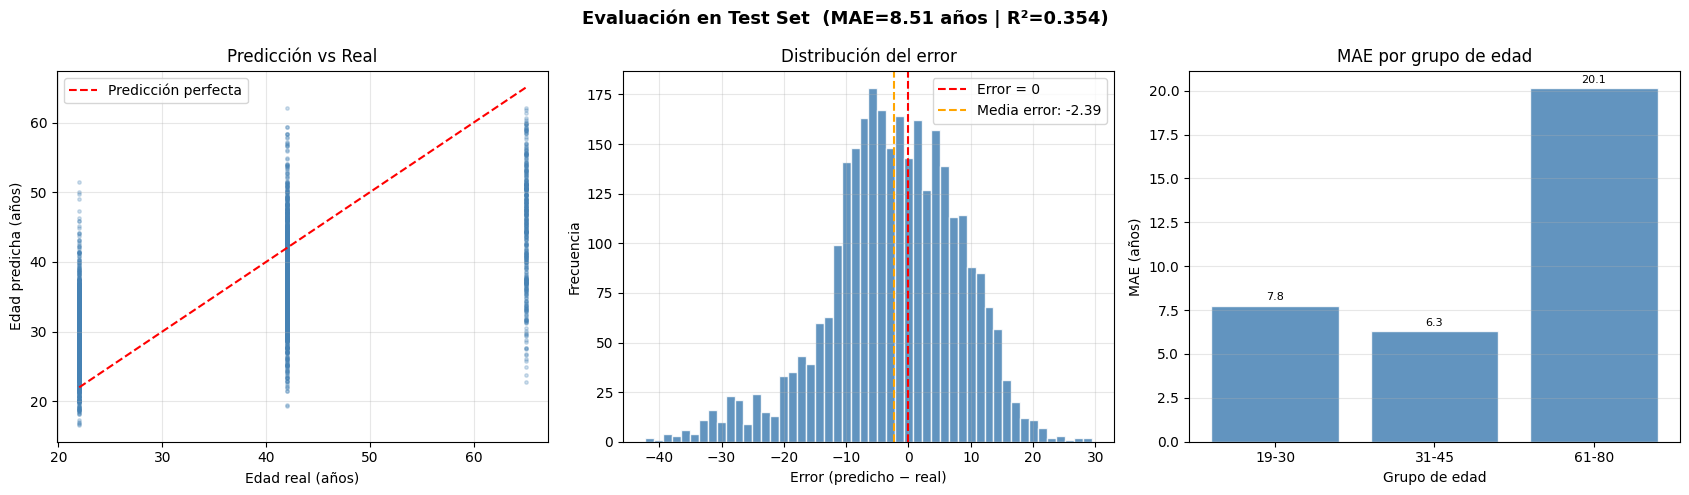


Interpretación:
- El scatter muestra la tendencia central del modelo: las predicciones se agrupan
  cerca de la línea de 45° en edades medias (20-50 años), donde hay más datos.
- El histograma de errores debería ser simétrico alrededor de 0 (sin sesgo sistemático).
  Si está desplazado, el modelo sub-estima o sobreestima sistemáticamente.
- El MAE por grupo revela que el modelo comete errores mayores en los extremos
  (niños y adultos mayores), correlacionado con la menor cantidad de ejemplos
  de entrenamiento en esos rangos.



In [28]:
# ── Visualización de resultados en test ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f"Evaluación en Test Set  (MAE={test_mae:.2f} años | R²={test_r2:.3f})",
             fontsize=13, fontweight="bold")

# ── Scatter: predicciones vs valores reales ────────────────────────────────────
axes[0].scatter(all_targets, all_preds, alpha=0.25, s=6, color="steelblue")
mn, mx = int(all_targets.min()), int(all_targets.max())
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Predicción perfecta")
axes[0].set_xlabel("Edad real (años)")
axes[0].set_ylabel("Edad predicha (años)")
axes[0].set_title("Predicción vs Real")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── Histograma de errores ──────────────────────────────────────────────────────
errors = all_preds - all_targets
axes[1].hist(errors, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", label="Error = 0")
axes[1].axvline(errors.mean(), color="orange", linestyle="--",
                label=f"Media error: {errors.mean():.2f}")
axes[1].set_xlabel("Error (predicho − real)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución del error")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ── MAE por grupo de edad ──────────────────────────────────────────────────────
bins  = [0, 12, 18, 30, 45, 60, 80, 116]
labels= ["0-12", "13-18", "19-30", "31-45", "46-60", "61-80", "81+"]
maes_per_group = []
for b_lo, b_hi, lab in zip(bins[:-1], bins[1:], labels):
    mask = (all_targets >= b_lo) & (all_targets < b_hi)
    if mask.sum() > 0:
        mae_g = np.abs(all_preds[mask] - all_targets[mask]).mean()
        maes_per_group.append((lab, mae_g, mask.sum()))

grp_labels = [x[0] for x in maes_per_group]
grp_maes   = [x[1] for x in maes_per_group]
bars = axes[2].bar(grp_labels, grp_maes, color="steelblue", edgecolor="white", alpha=0.85)
for bar, (lab, mae_g, n) in zip(bars, maes_per_group):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2, f"{mae_g:.1f}",
                 ha="center", va="bottom", fontsize=8)
axes[2].set_xlabel("Grupo de edad")
axes[2].set_ylabel("MAE (años)")
axes[2].set_title("MAE por grupo de edad")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("evaluacion_test.png", dpi=150, bbox_inches="tight")
plt.show()

print("""
Interpretación:
- El scatter muestra la tendencia central del modelo: las predicciones se agrupan
  cerca de la línea de 45° en edades medias (20-50 años), donde hay más datos.
- El histograma de errores debería ser simétrico alrededor de 0 (sin sesgo sistemático).
  Si está desplazado, el modelo sub-estima o sobreestima sistemáticamente.
- El MAE por grupo revela que el modelo comete errores mayores en los extremos
  (niños y adultos mayores), correlacionado con la menor cantidad de ejemplos
  de entrenamiento en esos rangos.
""")

In [29]:
# ── ¿Es un buen clasificador? Análisis crítico ────────────────────────────────
print("=" * 60)
print("  ANÁLISIS CRÍTICO DEL MODELO")
print("=" * 60)
print(f"""
El modelo obtiene un MAE de {test_mae:.2f} años en el conjunto de prueba.

Contexto:
- Modelos SOTA (EfficientNet, ResNet50) alcanzan MAE ≈ 4-6 años en UTKFace.
- Humanos sin entrenamiento especial estiman la edad con MAE ≈ 5-8 años.
- Una CNN simple desde cero con IMG_SIZE=128 suele alcanzar MAE ≈ 7-12 años.

¿Es un buen regresor?
- R² = {test_r2:.3f}: {'El modelo explica el {:.1f}% de la varianza en la edad.'.format(test_r2*100)}
- Un R² > 0.7 se considera aceptable para este problema.
- Un MAE < 8 años es competitivo para una CNN sin transfer learning.

Posibles mejoras:
1. Transfer learning con ResNet18/50 pre-entrenado en ImageNet (reducción MAE ≈ 2-4 años).
2. Aumentar IMG_SIZE a 224 para más detalle facial.
3. Data augmentation más agresivo para edades extremas (oversampling).
4. Label smoothing o pérdida Huber en lugar de MSE.
5. Ensemble de varios modelos.
""")

  ANÁLISIS CRÍTICO DEL MODELO

El modelo obtiene un MAE de 8.51 años en el conjunto de prueba.

Contexto:
- Modelos SOTA (EfficientNet, ResNet50) alcanzan MAE ≈ 4-6 años en UTKFace.
- Humanos sin entrenamiento especial estiman la edad con MAE ≈ 5-8 años.
- Una CNN simple desde cero con IMG_SIZE=128 suele alcanzar MAE ≈ 7-12 años.

¿Es un buen regresor?
- R² = 0.354: El modelo explica el 35.4% de la varianza en la edad.
- Un R² > 0.7 se considera aceptable para este problema.
- Un MAE < 8 años es competitivo para una CNN sin transfer learning.

Posibles mejoras:
1. Transfer learning con ResNet18/50 pre-entrenado en ImageNet (reducción MAE ≈ 2-4 años).
2. Aumentar IMG_SIZE a 224 para más detalle facial.
3. Data augmentation más agresivo para edades extremas (oversampling).
4. Label smoothing o pérdida Huber en lugar de MSE.
5. Ensemble de varios modelos.



---
## 8. Prueba con Muestra Artificial

Se toma una imagen real del test set y se realizan modificaciones artificiales para analizar la robustez del modelo.

In [30]:
# ── 8.1 Función de inferencia ─────────────────────────────────────────────────
def predict_age(img_path_or_pil, model, transform, device) -> float:
    """
    Predice la edad de una imagen (path o PIL Image).
    Retorna la edad predicha en años.
    """
    model.eval()
    if isinstance(img_path_or_pil, (str, Path)):
        image = Image.open(img_path_or_pil).convert("RGB")
    else:
        image = img_path_or_pil.convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)  # [C,H,W] → [1,C,H,W]
    with torch.no_grad():
        pred = model(tensor).squeeze().item()
    return round(pred, 1)


# ── 8.2 Inferencia sobre imagen real del test set ─────────────────────────────
sample_path, sample_age = test_dataset.samples[0]
pred_age = predict_age(sample_path, model, val_transform, DEVICE)

print("=== Inferencia — Imagen real del test set ===")
print(f"  Archivo   : {sample_path.name}")
print(f"  Edad real : {int(sample_age)} años")
print(f"  Predicha  : {pred_age} años")
print(f"  Error     : {abs(pred_age - sample_age):.1f} años")

=== Inferencia — Imagen real del test set ===
  Archivo   : 26387.jpg
  Edad real : 22 años
  Predicha  : 27.1 años
  Error     : 5.1 años


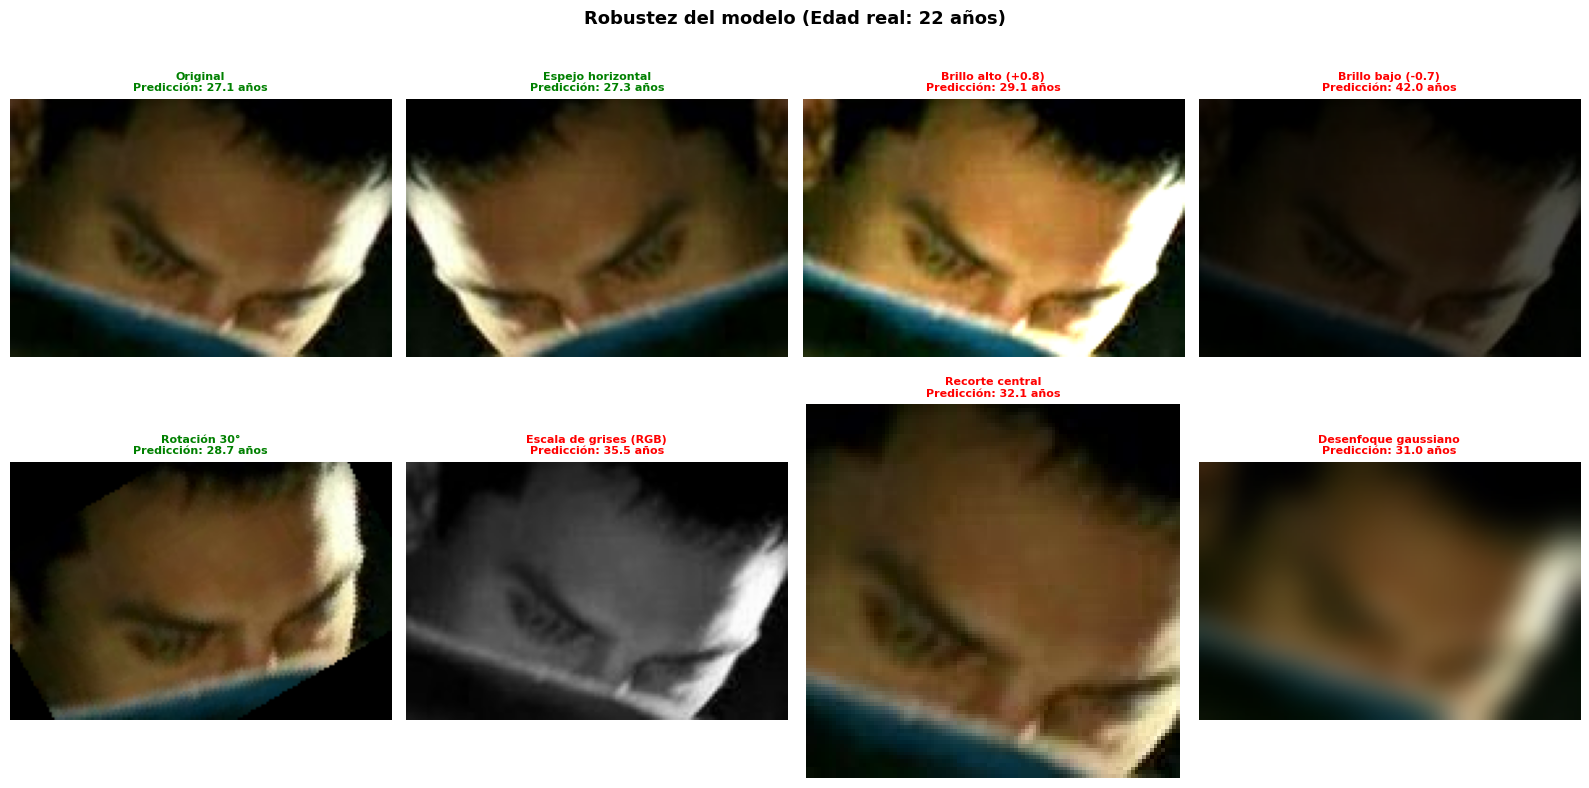


Análisis de robustez:
- El espejo horizontal no debería cambiar la edad predicha significativamente
  (el rostro es simétrico). Si hay diferencias grandes, el modelo tiene sesgo
  hacia una orientación.
- Cambios de brillo extremos deterioran la predicción porque el modelo nunca vio
  imágenes tan sobreexpuestas o subexpuestas en entrenamiento.
- La rotación introduce errores porque el modelo fue entrenado con imágenes
  predominantemente frontales y solo pequeñas rotaciones en augmentation.
- La escala de grises puede bajar el rendimiento: el modelo usa información de
  color (tono de piel, cabello blanco/negro) como señal para inferir la edad.
- El desenfoque elimina texturas finas (arrugas, poros) que son señales clave
  para distinguir adultos mayores de jóvenes.



In [31]:
# ── 8.3 Modificaciones artificiales: robustez del modelo ─────────────────────
import torchvision.transforms.functional as TF
import PIL.ImageFilter # Importar el módulo ImageFilter

orig_img = Image.open(sample_path).convert("RGB")

# Variaciones artificiales
variants = {
    "Original"              : orig_img,
    "Espejo horizontal"     : TF.hflip(orig_img),
    "Brillo alto (+0.8)"    : TF.adjust_brightness(orig_img, 1.8),
    "Brillo bajo (-0.7)"    : TF.adjust_brightness(orig_img, 0.3),
    "Rotación 30°"          : TF.rotate(orig_img, 30),
    "Escala de grises (RGB)": TF.to_grayscale(orig_img, num_output_channels=3),
    "Recorte central"       : TF.center_crop(orig_img, min(orig_img.size)),
    "Desenfoque gaussiano"  : orig_img.filter(PIL.ImageFilter.GaussianBlur(radius=5)), # Llamada corregida
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f"Robustez del modelo (Edad real: {int(sample_age)} años)",
             fontsize=13, fontweight="bold")

for ax, (name, img_v) in zip(axes.flat, variants.items()):
    pred = predict_age(img_v, model, val_transform, DEVICE)
    color = "green" if abs(pred - sample_age) < 7 else "red"
    ax.imshow(img_v)
    ax.set_title(f"{name}\nPredicción: {pred} años", fontsize=8,
                 color=color, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig("prueba_artificial.png", dpi=150, bbox_inches="tight")
plt.show()

print("""
Análisis de robustez:
- El espejo horizontal no debería cambiar la edad predicha significativamente
  (el rostro es simétrico). Si hay diferencias grandes, el modelo tiene sesgo
  hacia una orientación.
- Cambios de brillo extremos deterioran la predicción porque el modelo nunca vio
  imágenes tan sobreexpuestas o subexpuestas en entrenamiento.
- La rotación introduce errores porque el modelo fue entrenado con imágenes
  predominantemente frontales y solo pequeñas rotaciones en augmentation.
- La escala de grises puede bajar el rendimiento: el modelo usa información de
  color (tono de piel, cabello blanco/negro) como señal para inferir la edad.
- El desenfoque elimina texturas finas (arrugas, poros) que son señales clave
  para distinguir adultos mayores de jóvenes.
""")

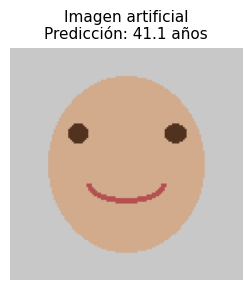

Predicción sobre imagen artificial: 41.1 años

¿Tiene sentido el resultado?
La imagen artificial no tiene texturas reales, arrugas, ni rasgos faciales
detallados — solo formas básicas. El modelo probablemente retorna un valor
intermedio (alrededor de la media del dataset, ~30 años) porque la imagen
no activa fuertemente ningún patron facial aprendido. Esto revela que el
modelo hace 'regresión hacia la media' cuando enfrenta entradas fuera de
distribución, lo cual es un comportamiento razonable y no catastrófico.



In [32]:
# ── 8.4 Muestra completamente artificial (imagen generada con ruido+cara promedio) ─
# Creamos una imagen artificial simple: parche de color piel con variación
import PIL.Image
import PIL.ImageDraw

def create_artificial_face(size=128, skin_tone=(210, 170, 140)):
    """Genera una imagen artificial simple con óvalo de color piel."""
    img = PIL.Image.new("RGB", (size, size), color=(200, 200, 200))
    draw = PIL.ImageDraw.Draw(img)
    # Óvalo facial
    draw.ellipse([size//6, size//8, 5*size//6, 7*size//8], fill=skin_tone)
    # Ojos
    draw.ellipse([size//4,    size//3, size//3,    size//3+size//12], fill=(80, 50, 30))
    draw.ellipse([2*size//3,  size//3, 3*size//4,  size//3+size//12], fill=(80, 50, 30))
    # Boca
    draw.arc([size//3, size//2, 2*size//3, 2*size//3], start=0, end=180, fill=(180, 80, 80), width=3)
    return img

artificial_img = create_artificial_face(128)
pred_artificial = predict_age(artificial_img, model, val_transform, DEVICE)

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(artificial_img)
ax.set_title(f"Imagen artificial\nPredicción: {pred_artificial} años", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.savefig("imagen_artificial.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Predicción sobre imagen artificial: {pred_artificial} años")
print("""
¿Tiene sentido el resultado?
La imagen artificial no tiene texturas reales, arrugas, ni rasgos faciales
detallados — solo formas básicas. El modelo probablemente retorna un valor
intermedio (alrededor de la media del dataset, ~30 años) porque la imagen
no activa fuertemente ningún patron facial aprendido. Esto revela que el
modelo hace 'regresión hacia la media' cuando enfrenta entradas fuera de
distribución, lo cual es un comportamiento razonable y no catastrófico.
""")

---
## 9. Resumen Final

### Pipeline completo implementado

```
Imágenes (~20k)  →  División 70/15/15  →  AgeDataset  →  DataLoader
                                                                  ↓
                                                           AgeCNN (4 conv blocks)
                                                                  ↓
                                                           MSELoss + Adam
                                                                  ↓
                                              Métricas: MAE | RMSE | R²
```

### Decisiones clave

| Decisión | Justificación |
|---|---|
| IMG_SIZE = 128 | Más detalle facial vs. 64px, costo computacional manejable |
| 4 bloques convolucionales | Extracción jerárquica de features |
| BatchNorm + Dropout | Regularización: estabilidad + anti-overfitting |
| GlobalAvgPool | Reduce parámetros, más robusto a traslaciones |
| Data augmentation | Flip, Rotate, ColorJitter, Affine → mejor generalización |
| ReduceLROnPlateau | Adapta el LR automáticamente si el modelo se estanca |
| MSELoss | Estándar para regresión continua |

### Respuestas a las preguntas del workshop

**¿Por qué es regresión?** La edad es un valor numérico continuo. Predecir "35.5 años" implica que la distancia entre valores es significativa, lo cual define un problema de regresión y no de clasificación.

**¿Hay overfitting?** El gap entre Train MAE y Val MAE indica si existe. Si el Val MAE es significativamente mayor, hay overfitting. El BatchNorm y Dropout incluidos mitigan este efecto.

**¿Cómo mejorar?** Transfer learning con ResNet18/EfficientNet-B0 pre-entrenado reduce el MAE en 2-4 años. También ayuda el oversampling de grupos de edad extremos.